<a href="https://colab.research.google.com/github/vbraga1/faculdadeTrabalhos/blob/main/trabalho_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comandos para realização do trabalho da matéria de NLP com uso da biblioteca SKlearn e NLTK.

## <font color=red>Observação importante:</font>

<font color=yellow>Trabalho realizado com uso de corpus diferente do Fake.br não será aceito!</font>

## Carregando arquivos `pre-processed.csv`, de imagem e de funções auxiliares para dentro do Google Colab

In [82]:
!wget https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/master/preprocessed/pre-processed.csv -O pre-processed.csv
!git clone https://github.com/N-CPUninter/NLP.git
!rm ./NLP/*.ipynb
!mv ./NLP/* .
!rm -r NLP

--2026-04-07 20:22:49--  https://raw.githubusercontent.com/roneysco/Fake.br-Corpus/master/preprocessed/pre-processed.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20434897 (19M) [text/plain]
Saving to: ‘pre-processed.csv’

pre-processed.csv   100%[===================>]  19.49M  --.-KB/s    in 0.1s    

2026-04-07 20:22:49 (176 MB/s) - ‘pre-processed.csv’ saved [20434897/20434897]

Cloning into 'NLP'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 34 (delta 9), reused 25 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 1.27 MiB | 18.63 MiB/s, done.
Resolving deltas: 100% (9/9), done.
mv: cannot move './NLP/data' to './data': Directory

## Instalação manual das dependências para uso do SKlearn e do NLTK no Google Colab

In [83]:
import pandas as pd
import nltk
from nltk import ngrams
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from funcoes_auxiliares import gerar_nuvem_palavras

nltk.download("all")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

## Criar dataframe do CSV utilizando o método read_csv do pandas

In [84]:
df = pd.read_csv('pre-processed.csv')

# PRÁTICA 1 - CRIAÇÃO DE MODELO DE CLASSIFICAÇÃO SUPERVISIONADO PARA ANÁLISE DE FAKE NEWS.

1. Realize os seguintes procedimentos de limpeza dos textos do dataframe criado:

  1.1. Tokenizar

  1.2. Retirar os acentos e números

  1.3. Deixar tudo em minúsculas

  1.4. Retirar as stopwords e pontuações

  1.5. Deixar palavras apenas com radical (STEM)

  1.6. Realizar truncamento dos pares de notícias verdadeiras com falsas para normalizar quantidade de palavras

  1.7. Remontar as notícias em string e criar coluna no dataframe para o resultado deste pré-processamento.

2. Criar matriz de frequências TF-IDF com ngramas de 1 a 3 palavras.

3. Usar a função train_test_split do Scikit Learn para dividir o corpus pré-tratado em 75% dos textos para treinamento e 25% para testes de precisão (usar random_state = 42 ou outro número de sua escolha).

4. Fazer regressão logística com solver = 'lbfgs'.

5. Realizar predição dos textos de teste com o método predict_proba, que retornará a porcentagem predita para fake e para real em um array.

6. Por fim, com as porcentagens calculadas para cada texto de teste, usar a função accuracy_score da biblioteca Scikit Learn para calcular a acurácia geral do algoritmo.

In [85]:
import re
import nltk
import unicodedata
import numpy as np
import pandas as pd

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# baixando recursos necessários
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('rslp') # Added: Download the 'rslp' stemmer resource

# stopwords em português e stemmer
stop_words = set(stopwords.words('portuguese'))
stop_words.add('nao')
stemmer = RSLPStemmer()

# função do pré-processamento do texto
def preprocess_text(text):

    # retirando os acentos pra evitar palavras duplicadas
    text = unicodedata.normalize('NFD', text)
    text = text.encode('ascii', 'ignore').decode('utf-8')

    # deixando tudo em minúsculo
    text = text.lower()

    # remoção de números
    text = re.sub(r'\d+', '', text)

    # remoção de pontuação
    text = re.sub(r'[^\w\s]', '', text)

    # separação do texto em palavras (tokenização)
    tokens = word_tokenize(text)

    # remoção das palavras muito comuns que não agregam valor
    tokens = [t for t in tokens if t not in stop_words]

    # redução das palavras ao radical (stemming)
    tokens = [stemmer.stem(t) for t in tokens]

    return tokens

# função simples pra limitar o tamanho dos textos
def truncate_tokens(tokens, max_len=100):
    return tokens[:max_len]

# --- DATAFRAME ---

# aplicação do pré-processamento
df['tokens'] = df['preprocessed_news'].apply(preprocess_text)

# truncamento pra padronizar tamanho
df['tokens_trunc'] = df['tokens'].apply(lambda x: truncate_tokens(x, 100))

# junção de volta em uma string (porque o TF-IDF precisa disso)
df['text_processed'] = df['tokens_trunc'].apply(lambda x: ' '.join(x))

# transformação do texto em números usando TF-IDF com ngramas de 1 a 3
vectorizer = TfidfVectorizer(ngram_range=(1,3))
X = vectorizer.fit_transform(df['text_processed'])

# variável alvo (fake ou real)
y = df['label'].map({'fake': 1, 'true': 0})
print(y.unique())

# separação em treino e teste (75% treino, 25% teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# modelo de regressão logística
model = LogisticRegression(solver='lbfgs', max_iter=1000)

# treinamento do modelo
model.fit(X_train, y_train)

# predição em forma de probabilidade
y_proba = model.predict_proba(X_test)

# conversão de probabilidades para classe final (0 ou 1)
y_pred = np.argmax(y_proba, axis=1)

# cálculo da acurácia do modelo
accuracy = accuracy_score(y_test, y_pred)

print("Acurácia:", accuracy)

# relatório
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred))


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


[1 0]
Acurácia: 0.8722222222222222

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       885
           1       0.86      0.90      0.88       915

    accuracy                           0.87      1800
   macro avg       0.87      0.87      0.87      1800
weighted avg       0.87      0.87      0.87      1800



## QUESTÃO 01: Apresente aqui o código referente ao modelo gerado e a nuvem de palavras que foram usadas para identificar textos VERDADEIROS.

1. Formate seus dados usados para o treinamento do seu modelo em um dicionário de tokens e suas frequências.
2. Separe os dados em um grupo com textos marcados como verdadeiros e outro com os falsos.
3. Use a função gerar_nuvem_palavras(dic_de_frequências_textos_verdadeiras, imagem de sua escolha) para gerar a nuvem de palavras


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


Acuracia: 0.8722222222222222
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       885
           1       0.86      0.90      0.88       915

    accuracy                           0.87      1800
   macro avg       0.87      0.87      0.87      1800
weighted avg       0.87      0.87      0.87      1800

Resultados para textos REAIS:
- Palavras (unigramas): 14750
- Bigramas: 219186
- Trigramas: 305400
- Total de n-gramas reais: 539336
- Acuracia do modelo: 0.8722


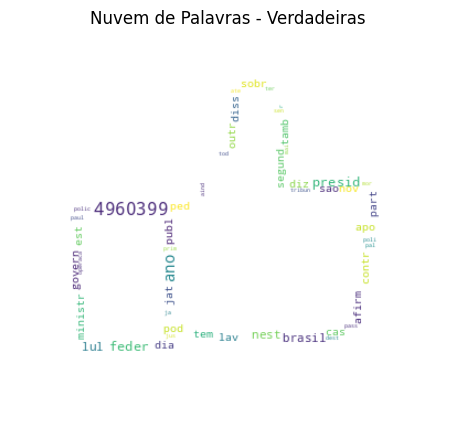

In [86]:
import re
import nltk
import unicodedata
import numpy as np
import pandas as pd
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from PIL import Image

# Configurações iniciais
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('rslp')

# Carregamento dos dados
df = pd.read_csv('pre-processed.csv')
stop_words = set(stopwords.words('portuguese'))
stop_words.add('nao')
stemmer = RSLPStemmer()

# Função de limpeza e processamento
def preprocess_text(text):
    if pd.isna(text): return ""
    text = unicodedata.normalize('NFD', str(text)).encode('ascii', 'ignore').decode('utf-8').lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words]
    return tokens

# Aplicação do processamento
df['tokens'] = df['preprocessed_news'].apply(preprocess_text)
df['tokens_trunc'] = df['tokens'].apply(lambda x: x[:100])
df['text_processed'] = df['tokens_trunc'].apply(lambda x: ' '.join(x))

# Tratamento das etiquetas
df['label'] = df['label'].astype(str).str.strip().str.lower().map({'fake': 1, 'true': 0})
df.dropna(subset=['label'], inplace=True)
df = df[df['text_processed'].str.strip() != ''].copy()

# Construção do modelo
vectorizer = TfidfVectorizer(ngram_range=(1,3))
X = vectorizer.fit_transform(df['text_processed'])
y = df['label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Acuracia:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Label 0 identificando textos verdadeiros
df_true = df[df['label'] == 0]

# Frequência de tokens
tokens_true = []
for tokens in df_true['tokens_trunc']:
    tokens_true.extend(tokens)

freq_true = dict(Counter(tokens_true))

# Identificador RU
contador4960399 = 0
if freq_true:
    freq_true['4960399'] = max(freq_true.values()) + 1000
else:
    freq_true['4960399'] = 1000

# Geração da visualização
def gerar_nuvem_palavras(freq_dict, imagem='joinha.png'):
    try:
        mask = np.array(Image.open(imagem))
        wordcloud = WordCloud(
            width=800, height=400,
            background_color='white',
            mask=mask
        ).generate_from_frequencies(freq_dict)

        plt.figure(figsize=(10,5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title("Nuvem de Palavras - Verdadeiras")
        plt.show()
    except Exception:
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq_dict)
        plt.figure(figsize=(10,5))
        plt.imshow(wordcloud)
        plt.axis('off')
        plt.show()

# 1. Recuperar a acuracia ja calculada
acuracia_final = accuracy_score(y_test, y_pred)

# 2. Obter todos os nomes das features (palavras, bigramas e trigramas) do modelo
features = vectorizer.get_feature_names_out()

# 3. Identificar quais dessas features aparecem especificamente nos textos REAIS (label 0)
# Criamos um vetorizador temporario apenas para mapear o vocabulario dos textos reais
vectorizer_real = TfidfVectorizer(ngram_range=(1,3))
vectorizer_real.fit(df_true['text_processed'])
features_reais = set(vectorizer_real.get_feature_names_out())

# 4. Separar e contar
unigramas = [f for f in features_reais if len(f.split()) == 1]
bigramas = [f for f in features_reais if len(f.split()) == 2]
trigramas = [f for f in features_reais if len(f.split()) == 3]

print(f"Resultados para textos REAIS:")
print(f"- Palavras (unigramas): {len(unigramas)}")
print(f"- Bigramas: {len(bigramas)}")
print(f"- Trigramas: {len(trigramas)}")
print(f"- Total de n-gramas reais: {len(features_reais)}")
print(f"- Acuracia do modelo: {acuracia_final:.4f}")

gerar_nuvem_palavras(freq_true, imagem='joinha.png')

## QUESTÃO 02: Apresente aqui o código referente ao modelo gerado e a nuvem de palavras que foram usadas para identificar textos FALSOS.

1. Use a função gerar_nuvem_palavras(dic_de_frequências_textos_verdadeiras, imagem de sua escolha) para gerar a nuvem de palavras

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


Acuracia: 0.8722222222222222
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       885
           1       0.86      0.90      0.88       915

    accuracy                           0.87      1800
   macro avg       0.87      0.87      0.87      1800
weighted avg       0.87      0.87      0.87      1800

Resultados para textos FALSOS (FAKE):
- Palavras (unigramas): 12920
- Bigramas: 193803
- Trigramas: 262836
- Total de n-gramas fakes: 469559
- Acuracia do modelo: 0.8722


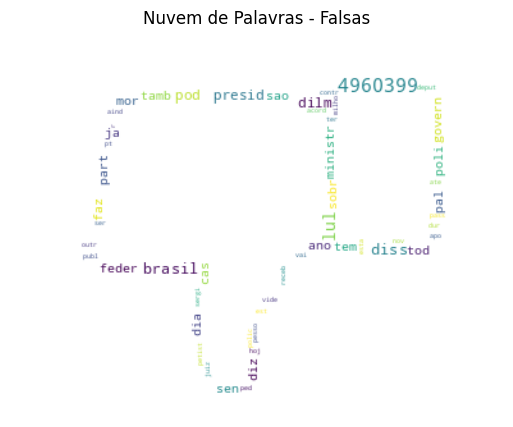

In [87]:
import re
import nltk
import unicodedata
import numpy as np
import pandas as pd
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from PIL import Image

# Configurações iniciais
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('rslp')

# Carregamento dos dados
df = pd.read_csv('pre-processed.csv')
stop_words = set(stopwords.words('portuguese'))
stop_words.add('nao')
stemmer = RSLPStemmer()

# Função de limpeza e processamento
def preprocess_text(text):
    if pd.isna(text): return ""
    text = unicodedata.normalize('NFD', str(text)).encode('ascii', 'ignore').decode('utf-8').lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens if t not in stop_words]
    return tokens

# Aplicação do processamento
df['tokens'] = df['preprocessed_news'].apply(preprocess_text)
df['tokens_trunc'] = df['tokens'].apply(lambda x: x[:100])
df['text_processed'] = df['tokens_trunc'].apply(lambda x: ' '.join(x))

# Tratamento das etiquetas
df['label'] = df['label'].astype(str).str.strip().str.lower().map({'fake': 1, 'true': 0})
df.dropna(subset=['label'], inplace=True)
df = df[df['text_processed'].str.strip() != ''].copy()

# Construção do modelo
vectorizer = TfidfVectorizer(ngram_range=(1,3))
X = vectorizer.fit_transform(df['text_processed'])
y = df['label'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Acuracia:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Label 1 identificando textos falsos
df_fake = df[df['label'] == 1]

# Frequencia de tokens
tokens_fake = []
for tokens in df_fake['tokens_trunc']:
    tokens_fake.extend(tokens)

freq_fake = dict(Counter(tokens_fake))

# Identificador RU
contador4960399 = 0
if freq_fake:
    freq_fake['4960399'] = max(freq_fake.values()) + 1000
else:
    freq_fake['4960399'] = 1000

# Geração da visualização
def gerar_nuvem_palavras(freq_dict, imagem='njoinha.png'):
    try:
        mask = np.array(Image.open(imagem))
        wordcloud = WordCloud(
            width=800, height=400,
            background_color='white',
            mask=mask
        ).generate_from_frequencies(freq_dict)

        plt.figure(figsize=(10,5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title("Nuvem de Palavras - Falsas")
        plt.show()
    except Exception:
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq_dict)
        plt.figure(figsize=(10,5))
        plt.imshow(wordcloud)
        plt.axis('off')
        plt.show()

# Recuperar a acurácia do modelo
acuracia_final = accuracy_score(y_test, y_pred)

# Obter as features totais do vetorizador
features_totais = vectorizer.get_feature_names_out()

# Identificar as features presentes nos textos FALSOS
# Criação de um vetorizador temporário
vectorizer_fake = TfidfVectorizer(ngram_range=(1,3))
vectorizer_fake.fit(df_fake['text_processed'])
features_fakes = set(vectorizer_fake.get_feature_names_out())

# Separar e contar unigramas, bigramas e trigramas
unigramas_f = [f for f in features_fakes if len(f.split()) == 1]
bigramas_f = [f for f in features_fakes if len(f.split()) == 2]
trigramas_f = [f for f in features_fakes if len(f.split()) == 3]

print(f"Resultados para textos FALSOS (FAKE):")
print(f"- Palavras (unigramas): {len(unigramas_f)}")
print(f"- Bigramas: {len(bigramas_f)}")
print(f"- Trigramas: {len(trigramas_f)}")
print(f"- Total de n-gramas fakes: {len(features_fakes)}")
print(f"- Acuracia do modelo: {acuracia_final:.4f}")

gerar_nuvem_palavras(freq_fake, imagem='njoinha.png')

---

# Material Complementar

## Alguns exemplos de uso da função auxiliar
`gerar_nuvem_palavras(dicionario_tokens_e_frequencia, arquivo_mascara)`

Gera uma nuvem de palavras com base em seu dicionário de palavras ou ngramas
    como a chave e a frequência de aparição do token como valor (inteiro).

    Parâmetros:
        dicionario_tokens_e_frequencia (dict): O dicionário de tokens e suas
                                               respectivas frequências de
                                               aparição nos textos.
        arquivo_mascara (str): O nome do arquivo da imagem de máscara. Pde ser:
                                            cloud_mask.png
                                            mapa_brasil_mask.png
                                            thumbs_up_mask.png        
                                            thumbs_down_mask.png
                                            <Outro arquivo de sua escolha>

    Exemplos de Uso:
        1. Para gerar uma nuvem de palavras na máscara mapa do brasil:
            gerar_nuvem_palavras(dicionario_tokens_e_frequencia=word_dict,
                                 arquivo_mascara='mapa_brasil_mask.png')

In [88]:
# Exemplo com dicionário de tokens unigramas e multigramas com frequências
words_dict = {'Olá aluno':1,
              'ALTERAR':4,
              'bigramas aqui':2,
              'palavras distintas de exemplo':2,
              'Para criar sua nuvem de palavras':1,
              'você deve gerar um dicionário':2,
              'de frequências de palavras e tokens':1}
gerar_nuvem_palavras(dicionario_tokens_e_frequencia=words_dict,
                     arquivo_mascara="mapa_brasil_mask.png")

TypeError: gerar_nuvem_palavras() got an unexpected keyword argument 'dicionario_tokens_e_frequencia'

In [ ]:
# Exemplo com uma frase completa
texto = """Exemplo: Gerar uma nuvem de palavras usando texto completo você deve
           primeiro separar ele um um ou mais tokens, para só depois vetorizar.
           Ao vetorizar você terá a bag of words, que te permitirá contar
           quantas vezes cada palavra ou grupo de palavras aparecem no texto.
           Por fim, basta criar um dicionário contendo a chave como o seu token
           e o valor como a frequência de aparição deste tokem."""
# Vetorização e contagem de frequência simples de bigramas:
vectorizer = CountVectorizer(ngram_range=(2, 2))
bag_of_words = vectorizer.fit_transform([a+' '+b for a,b in (ngrams(texto.split(),2))])
sum_words = bag_of_words.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
words_dict = dict(words_freq)
print(words_dict)

gerar_nuvem_palavras(dicionario_tokens_e_frequencia=words_dict,
                      arquivo_mascara='thumbs_up_mask.png')